# 11. Quantum Teleportation


Teleportation might sound like something out of science fiction, but in the realm of quantum mechanics, it's already a reality. Thanks to advances in quantum computing, we can now implement quantum teleportation using existing technology. This remarkable process is built upon several fundamental principles of quantum theory—such as the no-cloning theorem, quantum entanglement, and the principle of deferred measurement—each playing a crucial role in making teleportation possible. In the following, you'll learn and explore how to use these principles to transfer the quantum state of a qubit from a sender (Alice) to a receiver (Bob), without physically moving the qubit itself. This is the essence of quantum teleportation.

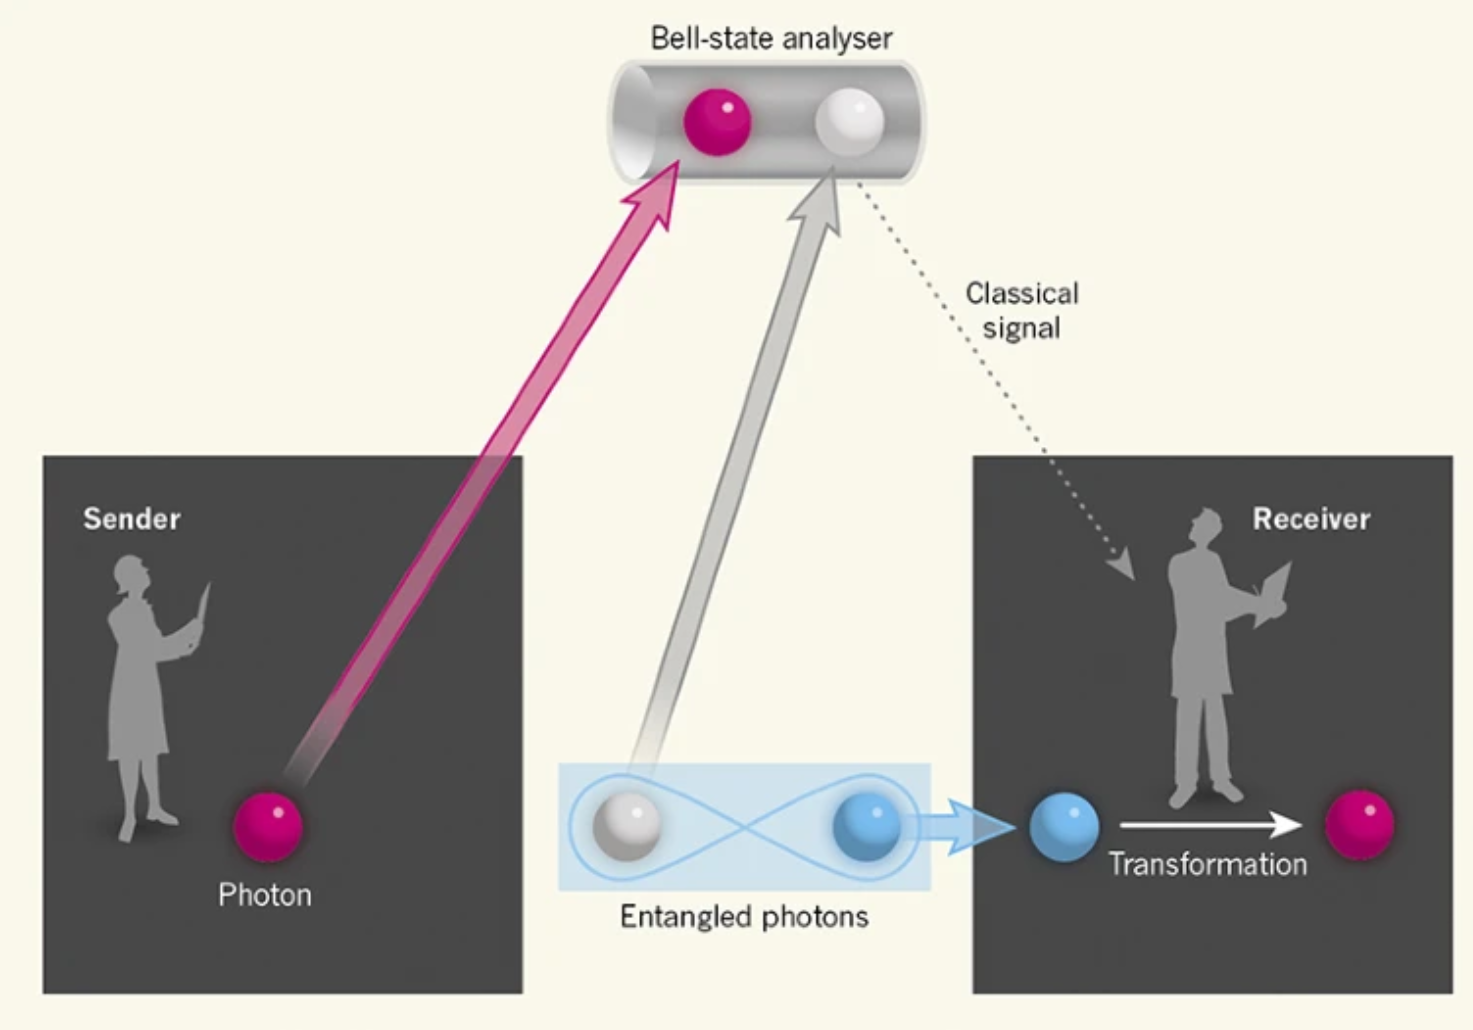

Image from https://www.nature.com/articles/d41586-017-07689-5


## Motivation for Quantum Teleportation

In classical communication, data can be copied, measured, and repeated freely. Quantum information is different: an unknown qubit cannot be perfectly measured or cloned (the no-cloning theorem), so simply “reading off” and re-sending a quantum state is impossible.

Moreover, transmitting a qubit directly through a lossy fiber or free-space link can degrade the quantum signal with distance. These constraints motivated Bennett et al. to propose quantum teleportation (1993) as a new communication primitive https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.70.1895. Teleportation uses a pre-shared entangled pair and classical bits to transfer a qubit’s state without moving the particle itself. This protocol "disassembles" an unknown qubit into shared entanglement and two classical bits, and later “reassembles” it at the receiver. In other words, teleportation trades the problem of sending fragile qubits for the problem of distributing entanglement in advance, which can be easier to manage and passing classical information later.

## Teleportation Protocol

The teleportation protocol works as follows.

**Step 1:** Alice and Bob share a maximally-entangled pair of qubits -- a Bell pair.  There are four different Bell pair states:

$|q_A q_B⟩ = |\Phi^+⟩ = \frac{1}{2}(|00⟩+|11⟩)$

$|q_A q_B⟩ = |\Phi^-⟩ = \frac{1}{2}(|00⟩-|11⟩)$

$|q_A q_B⟩ = |\Psi^+⟩ = \frac{1}{2}(|01⟩+|10⟩)$

$|q_A q_B⟩ = |\Psi^+⟩ = \frac{1}{2}(|01⟩-|10⟩)$

Any of these four can be used, although it changes the details of the protocol. Here we will assume they use $|\Phi^+⟩$.  At this point, the three qubits are in the state

$|\varphi\rangle_C\otimes|\Phi^+\rangle_{AB} = (\alpha |0\rangle_C + \beta|1\rangle_C)\otimes\frac{1}{\sqrt{2}} (|0\rangle_A \otimes |0\rangle_B + |1\rangle_A \otimes |1\rangle_B)$

**Step 2:** Alice takes her half of the entangled pair (system A) and the unknown input qubit |φ⟩, performs a measurements on both of them in the Bell-pair basis:

$|0\rangle \otimes |0\rangle = \frac{1}{\sqrt{2}} (|\Phi^+\rangle + |\Phi^-\rangle)$

$|0\rangle \otimes |1\rangle = \frac{1}{\sqrt{2}} (|\Psi^+\rangle + |\Psi^-\rangle)$

$|1\rangle \otimes |0\rangle = \frac{1}{\sqrt{2}} (|\Psi^+\rangle - |\Psi^-\rangle)$

$|1\rangle \otimes |1\rangle = \frac{1}{\sqrt{2}} (|\Phi^+\rangle - |\Phi^-\rangle)$

**Can you work out what the state looks like after this basis change?**

Hopefully you found

$\begin{align}
| & \varphi\rangle_C \otimes\ |\Phi^+\rangle_{AB} \   =
\frac{1}{2} \Big \lbrack
\ |\Phi^+\rangle_{CA} \otimes (\alpha |0\rangle_B + \beta|1\rangle_B)
\ + \ |\Phi^-\rangle_{CA} \otimes (\alpha |0\rangle_B - \beta|1\rangle_B)\\
& \phantom{xxxxxxxxxxxxxxxxx}\ + \  |\Psi^+\rangle_{CA} \otimes (\alpha |1\rangle_B + \beta|0\rangle_B)
\ + \ |\Psi^-\rangle_{CA} \otimes (\alpha |1\rangle_B - \beta|0\rangle_B) \Big \rbrack . \\
\end{align}$

where $\alpha,\beta$ are the parameters defining the original $|\varphi\rangle$ state.

So, she performs a set of gates to transform the pair $|φq_A\rangle$ into this basis and then measure them in one of the four states, indexed by two classical bits $c_C,c_A$:

* $|\Phi^+\rangle_{CA} \otimes (\alpha |0\rangle_B + \beta|1\rangle_B)$
* $|\Phi^-\rangle_{CA} \otimes (\alpha |0\rangle_B - \beta|1\rangle_B)$
* $|\Psi^+\rangle_{CA} \otimes (\alpha |1\rangle_B + \beta|0\rangle_B)$
* $|\Psi^-\rangle_{CA} \otimes (\alpha |1\rangle_B - \beta|0\rangle_B)$

Notice that while Bob's qubit now has $\alpha,\beta$ coefficients, but they may not be on the correct state or have a minus sign, depending on which classical state Alice's qubits are in.  Thus the result of Alice's measurement tells her which of the above four states the system is in.

**Step 3:** She then sends those two bits over an ordinary classical channel to Bob.  This takes an amount of time no faster than the time it takes light to travel between the two.


**Step 4:** Upon receiving them, Bob applies one of four possible single-qubit unitaries to his half of the Bell pair |q_b⟩, which transforms it into $|\varphi\rangle=\alpha |0\rangle_B + \beta|1\rangle_B$.

*Case 1* If Alice indicates her result is $|\Phi^+\rangle_{CA}$, Bob knows his qubit is already in the desired state and does nothing. This amounts to the trivial unitary operation, the identity operator.

*Case 2* If the message indicates $|\Phi^-\rangle_{CA}$, Bob would apply a $Z$ gate to his qubit to recover the state.

*Case 3* For $|\Psi^+\rangle_{CA}$, Bob applies an $X$ gate to his qubit.

**Can you work out the gate that should be applied in the case that $|\Psi^-\rangle_{CA}$ is measured?**

## Teleportation for Long-Distance Communication


A useful way to think about teleportation is as sending a quantum “text message” through a pre-established quantum “portal.” The entangled pair acts like a portal connecting Alice and Bob, even if they are far apart. When Alice measures and sends the classical bits (the “text”), Bob uses his half of the portal to reconstruct the quantum message. Teleportation is especially powerful in overcoming channel loss: instead of sending photons over many kilometers (where loss grows exponentially), one can first establish entanglement (retrying until successful) and then teleport the state.

In fact, we have one such network here at the lab, connecting us to downtown Chicago and Argonne National Lab.

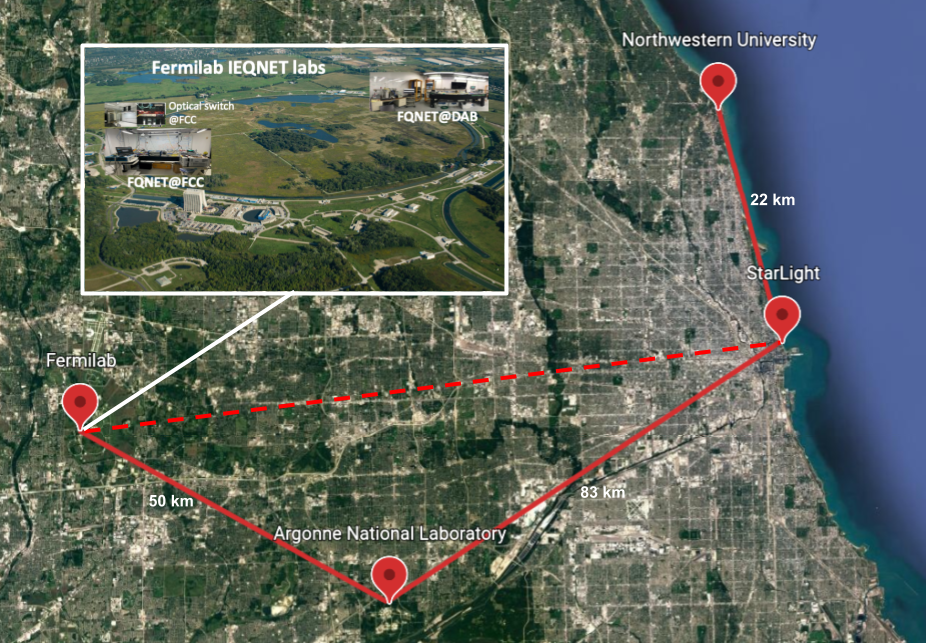




Channel losses can be mitigated by quantum repeaters: intermediate nodes that generate entanglement in shorter segments and swap it into a long-distance link. Teleportation can then occur over arbitrarily long distance by first stitching together these entangled links. This strategy underlies proposals for a global “quantum internet.” In practice, teleportation experiments have now reached very long ranges – for example, a groundbreaking satellite experiment teleported qubit states over 1,400 kilometers– demonstrating that long-range quantum communication via teleportation is feasible. (Indeed, it's necessary for large-scale quantum networks and distributed quantum computation https://arxiv.org/abs/1707.00934.)

Further advantages are:

* Overcoming channel loss: A direct fiber link would lose qubits exponentially with distance, but with teleportation you only need to send heralded entanglement and classical bits. By repeating entanglement attempts and using entanglement swapping (the core of a quantum repeater), one can extend the teleportation range.

* Beyond networking long distances, the robustness to noise leads to a practical application within a single quantum computer called state injection which enables fault-tolerant computation.

## The No-Cloning Theorem and Its Importance

So, this entire time we have be working hard to teleport quantum states, you probably have been wondering: "Why not just copy the state?"  Well, quantum mechanics comes in and ruins your day if you try that.  So much so that this obstacle has a name -- The no-cloning theorem -- and is one of the most fundamental results in quantum mechanics. It states that it is **impossible to create an exact copy of an arbitrary unknown quantum state**. This result was formalized in 1982 by Wootters and Zurek, and independently by Dieks, and it follows directly from the linearity of quantum operations.  As an aside, because it arises from a fundamental postulate of quantum mechanics, attempts to combine quantum mechanics and general relativity can often cause wild things to happen in quantum computers.

To understand the theorem, consider a qubit in some unknown state

$∣ψ⟩=α∣0⟩+β∣1⟩$.

Suppose we had a "cloning machine" that could take this state and an auxiliary blank qubit ∣0⟩ and produce two copies:

$∣ψ⟩⊗∣0⟩→∣ψ⟩⊗∣ψ⟩$

However, quantum mechanics only allows unitary (i.e., linear and reversible)operations. If this machine worked for two states$∣ψ_1⟩$ and $∣ψ_2⟩$, linearity would require:

$U[(a∣ψ_1⟩+b∣ψ_2⟩)⊗∣0⟩]=a∣ψ_1⟩⊗∣ψ_1⟩+b∣ψ_2⟩⊗∣ψ_2⟩$

But this is not equal to:

$(a∣ψ_1⟩+b∣ψ_2⟩)⊗(a∣ψ_1⟩+b∣ψ_2⟩)$

unless $∣\psi_1⟩$ and $∣\psi_2⟩$ are orthogonal. Thus, a universal cloning machine that works for all states cannot exist.



Some more useful references for the following tutorial are:

https://www.youtube.com/watch?v=jxqnzltpDdE

https://pennylane.ai/qml/demos/tutorial_teleportation

https://github.com/qiskit-community/qiskit-community-tutorials/blob/master/awards/teach_me_quantum_2018/intro2qc/7.Quantum%20teleportation.ipynb

## Let's Start Teleporting!

In [ ]:
%pip install qiskit qiskit-ibm-runtime qiskit-aer
!pip install pylatexenc matplotlib

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_state_city, plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
import numpy as np
from qiskit.visualization import array_to_latex
import matplotlib.pyplot as pltb

### Step 1: Prepare a state to teleport

We'll use a single qubit initialized in a general quantum state

$|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$.

To start, we'll use the state:


$$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$

This is known as the ∣+⟩ state, and it can be easily created by applying a Hadamard gate to the ∣0⟩ state.

In our setup:
- Qubit 0 will hold the state ∣ψ⟩ to be teleported.
- Qubit 1 belongs to Alice, who performs the teleportation.
- Qubit 2 belongs to Bob, who will receive the teleported state.

We'll entangle qubits 1 (Alice) and 2 (Bob), and then use qubit 0 (the state to teleport) along with Alice's qubit to carry out the teleportation protocol.

* To start off, lets use the next cell to set up a 3 qubit, 3 bit circuit and apply a Hadamard gate to the $|\psi\rangle$ qubit.
* Then draw the circuit to check things worked correctly.

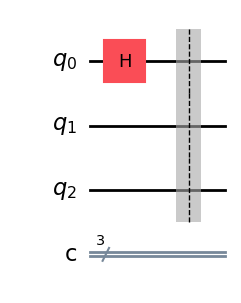

In [3]:
# Step 1: Prepare the quantum circuit
qc = QuantumCircuit(3, 3)

# Prepare the state to be teleported on qubit 0 by adding a hadamard gate
qc.h(0)

qc.barrier()
qc.draw('mpl')

### Step 2: Entangle Alice’s and Bob’s Qubits
To enable quantum teleportation, Alice and Bob must share an entangled pair of qubits. This entanglement acts as a quantum channel between them—it’s what makes teleportation possible without physically sending the qubit.

The type of entangled state we use is a Bell state, specifically:

$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

This state has two key properties that make it ideal for teleportation:

* Maximal entanglement: Measurement of one qubit instantly determines the state of the other, regardless of the distance between them.
* Correlated outcomes: The two qubits in the Bell pair are perfectly correlated in the computational basis, which is essential for transferring the quantum information correctly.
In our circuit:

Qubit 1 (Alice) and Qubit 2 (Bob) will form the Bell pair.
This entanglement is created using a Hadamard gate on qubit 1 followed by a CNOT gate from qubit 1 to qubit 2

* Using the same circuit you prepared above, add a Hadamard gate to the Alice qubit, and entangle it with a CNOT to the Bob qubit.


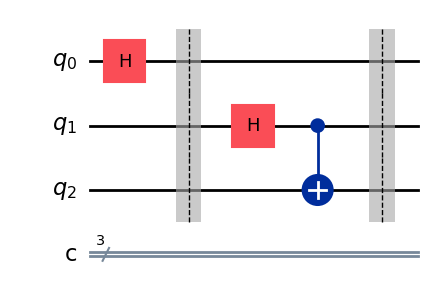

In [4]:
# Add the corresponding Hadamard and CNOT gates
qc.h(1)
qc.cx(1, 2)

qc.barrier()
qc.draw('mpl')

### Step 3: Alice performs a Bell measurement

Step 3: Alice Performs a Bell Measurement

Now that qubit 0 holds the state ∣ψ⟩ (the one to be teleported), and qubits 1 and 2 are entangled in the Bell state ∣Φ+⟩, Alice can proceed with her Bell-state measurement on her two qubits: qubit 0 (the state ∣ψ⟩) and qubit 1 (her part of the Bell pair).

To implement a Bell measurement on qubits 0 and 1, Alice:

1) Applies a CNOT gate with qubit 0 as control and qubit 1 as target.

2) Applies a Hadamard gate on qubit 0.

3) Measures qubits 0 and 1 in the computational basis and stores the results in classical bits.

These gates effectively rotate the Bell basis back into the standard computational basis, so that a regular measurement can distinguish between the Bell states.

* Implement the additional circuitry above in the next cell

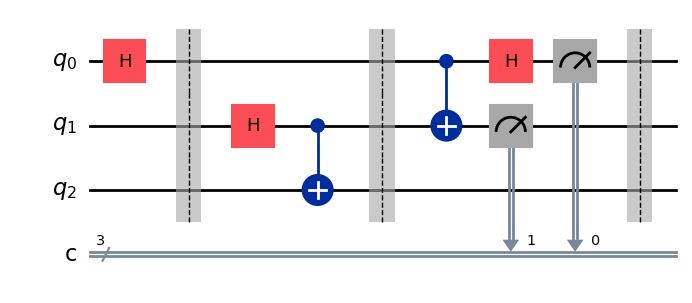

In [5]:
# Alice applies CNOT and H
qc.cx(0, 1)
qc.h(0)

# Measure Alice's qubits (0 and 1)
qc.measure([0, 1], [0, 1])

qc.barrier()
qc.draw('mpl')

Now lets add a `save_statevector()` to our circuit, such that we can set what quantum state the quantum computer would be in.  

Note **This is not a real operation we can do on a true computer**

In [6]:
# Save the statevector for visualization
qc.save_statevector()

Now, let's set up a backend and run the simulation, and look at what the statevector looks like.  Try running the cell a few times and notice what happens to the various amplitudes.

<IPython.core.display.Latex object>

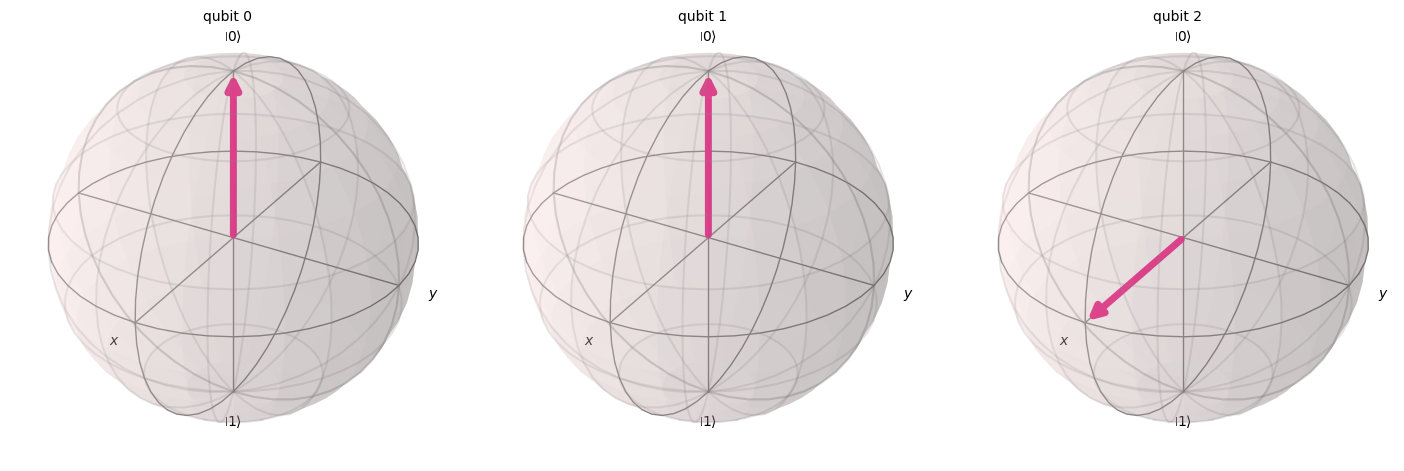

In [7]:
# Use the Aer simulator
backend = AerSimulator()

# Run the circuit
result = backend.run(qc).result()

# Extract final statevector
state = result.get_statevector()

# Plot Bloch sphere for all qubits (Bob's is qubit 2)
display(array_to_latex(state, prefix="\\text{Statevector} = "),plot_bloch_multivector(state))

Presumably, you saw that as you rerun the simulator, all three of the qubits change their state.  Lets add some `measure` functions for Alice's two qubits, and then observe the counts.

In [8]:
qc.measure(2,2)
result = backend.run(qc).result()
print(result.get_counts())

{'001': 118, '100': 123, '110': 111, '010': 111, '000': 147, '101': 141, '011': 136, '111': 137}


You should get a list that includes 3 qubit states with counts roughly evenly distributed....but honestly this isn't terribly clear that you have really done anything besides chaos.

Before we specifically perform the rotations and measurements on Bob's qubit, lets check if we are at least in the ballpark by using `marginal_counts`.

First `from qiskit.result import marginal_counts`  This will allow us to perform simulations, and then return counts that have summed over qubits we don't care about.  So in this case q0, q1.

`marginal_counts(result_of_backend, indices=[list_of_qubits_to_keep])`
This function takes a result from a backend, and then sums over any qubit not in the list of indices.  Try and use this function in the next cell.

In [9]:
from qiskit.result import marginal_counts
marginalised_results = marginal_counts(result, indices=[2])
marginalised_counts = marginalised_results.get_counts()
print(marginalised_counts)

{'0': 512, '1': 512}


### Question: Why a Bell Measurement?

Write the answer below

A Bell measurement projects two qubits onto the Bell basis:

$|\Phi^\pm\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle \pm |11\rangle\right)$


$|\Psi^\pm\rangle = \frac{1}{\sqrt{2}}\left(|01\rangle \pm |10\rangle\right)$

This operation entangles qubits 0 and 1 and collapses their joint state into one of these four possibilities. Importantly, this also determines how Bob must correct his qubit (qubit 2) to recover the original ∣ψ⟩.

### Conceptual Exercise

After Alice’s measurement, Bob’s qubit is projected into a state that depends on her outcome.

**Q:** What are the four possible outcomes, and what corrections must Bob apply to recover $|\varphi\rangle$?

Hint: See the table below and match each classical bit string to the correct operation

| Alice's Result | Bob Applies |
|----------------|-------------|
| 00             | ___         |
| 01             | ___         |
| 10             | ___         |
| 11             | ___         |


Answer:

| Alice's Result | Bob Applies  |
| -------------- | ------------ |
| 00             | $I$          |
| 01             | $X$          |
| 10             | $Z$          |
| 11             | $XZ$ or $iY$ |


After Alice performs her Bell measurement on qubits 0 and 1, the joint 3-qubit state collapses. Bob's qubit (qubit 2) ends up in a modified version of the original state ∣ψ⟩, depending on which Bell state Alice's two qubits collapsed into.

Each of the 4 possible outcomes of Alice's 2-bit measurement corresponds to one of the 4 Bell states written in the table above. Therefore, Bob must apply a unitary correction to reverse this transformation and recover the original state ∣ψ⟩.



### Exercise 1: Corrections using conditionals

Repeat the teleportation protocol, but this time simulate the classical communication step explicitly using conditional functions.  To do this, we will use case and switch methods.

The first line establishes a switch based on a set of classical bits:

`with circuit.switch(classical_bits_in_circuit) as case:`

and then indenting in python, you can declare `with case(value):` and then declare what new gates to implement.  `value` can be declared in integers e.g. 0,1,2,3 or binary eg `0b001`, `0b010`, `0b011`.

**Note, the qubits are ordered from right to left e.g. your $q_0$, $q_1$, and $q_2$ would be written in binary as $q_2 q_1 q_0$**

After measuring Alice’s qubits, use classical if statements to apply the appropriate correction to Bob’s qubit based on the outcome.

Your task:

* Prepare a general quantum state on Qubit 0 that randomly prepares a state using the `circuit.u(theta,phi,lambda)` gate.
*Create a Bell pair between Qubits 1 (Alice) and 2 (Bob).
*Perform a Bell-state measurement on Qubits 0 and 1.
*Measure Alice’s qubits and store the outcome.
*Based on the classical measurement result, apply correction gates to Bob’s qubit in a new circuit using classical logic.
*Visualize Bob’s final state to confirm successful teleportation using `statevector`.


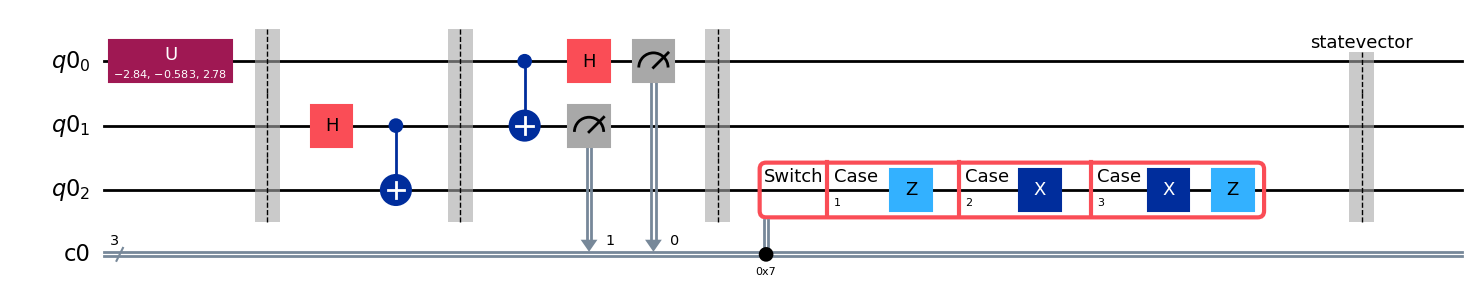

In [10]:
#Circuit setup
qubits = QuantumRegister(3)
clbits = ClassicalRegister(3)
qc_correct = QuantumCircuit(qubits, clbits)

#Randomly sample the angles and implement the rotation on qubit 0
theta, phi, lam = (2*np.random.rand()-1)*np.pi, (2*np.random.rand()-1)*np.pi, (2*np.random.rand()-1)*np.pi
qc_correct.u(theta, phi, lam, 0)

qc_correct.barrier()

#Create the Bell pair
qc_correct.h(1)
qc_correct.cx(1, 2)

qc_correct.barrier()

#Measure the Bell states
qc_correct.cx(0, 1)
qc_correct.h(0)
qc_correct.measure(0, 0)
qc_correct.measure(1, 1)

qc_correct.barrier()

#Use the classical bits to apply gates to Bob's qubit
with qc_correct.switch(clbits) as case:
    with case(0b001):
        qc_correct.z(2)
    with case(0b010):
        qc_correct.x(2)
    with case(0b011):
        qc_correct.x(2)
        qc_correct.z(2)

#Save the state vector and draw the circuit to check
qc_correct.save_statevector()
qc_correct.draw("mpl")

Hopefully, your circuit looks something like:

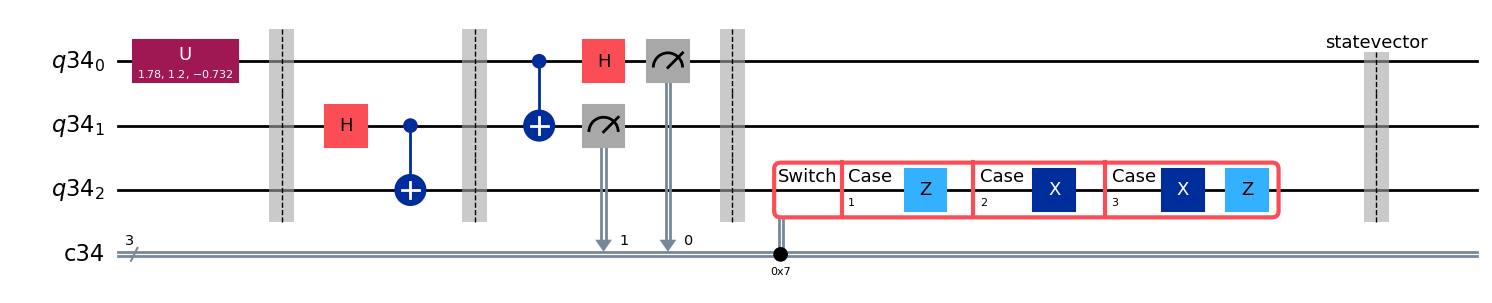

Now, lets again run a simulation with a backend and look at the state vector.  Do you notice anything about the behavior of the 3 qubits?

<IPython.core.display.Latex object>

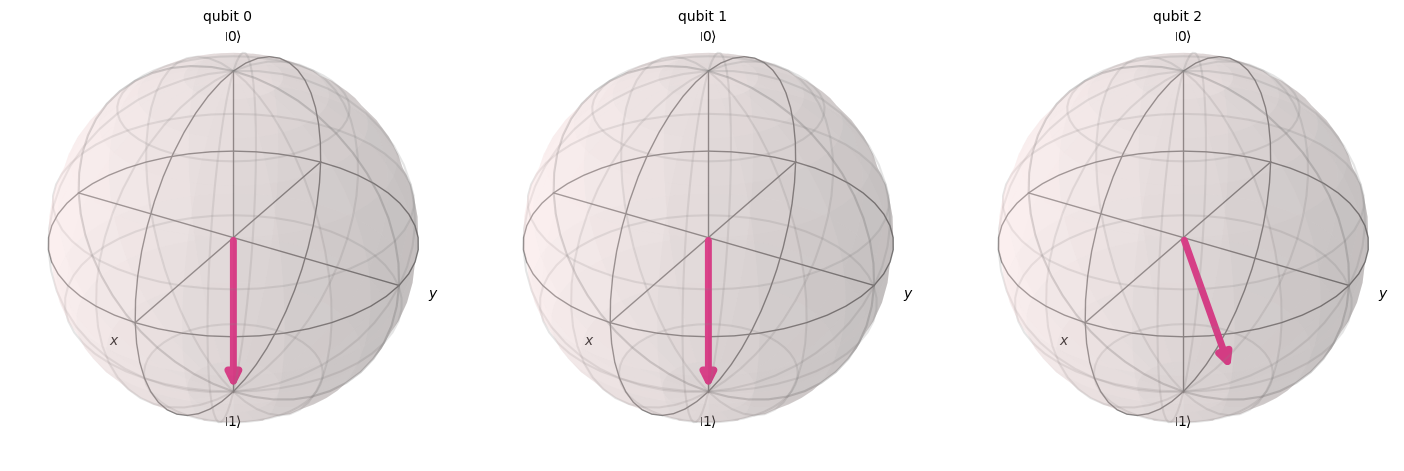

In [11]:
# Simulate final statevector

result = backend.run(qc_correct).result()
state = result.get_statevector()

# Plot Bloch sphere for all qubits (Bob's is qubit 2)
display(array_to_latex(state, prefix="\\text{Statevector} = "),plot_bloch_multivector(state))

Again, let's repeat the sets of measuring the marginalized counts for Bob's qubit.

In [12]:
qc_correct.measure(2,2)
result = backend.run(qc_correct).result()
marginalised_results = marginal_counts(result, indices=[2])
marginalised_counts = marginalised_results.get_counts()
print(marginalised_counts)

{'0': 25, '1': 999}


You should now have 1024 shots, that are distributed between the |0> and |1> state of Bob's qubit.  In the next cell, compute the probability for each state, and compare it to the predicted value from the initial state you randomly prepared.

Do you agree?  How are you confident you agree or disagree?

In [13]:
total = sum(marginalised_counts.values())
for s, cnt in sorted(marginalised_counts.items()):
    print(f'P(|{s}>) = {cnt/total:.3f}')

P(|0>) = 0.024
P(|1>) = 0.976


But, perhaps we shouldn't be so sure we have successfully teleported the quantum state?  This simulation only confirmed that we get the same classical probability out at the end.  So let's try some more diagnostics.

### Exercise 2: Fidelity between the original qubit state and the teleported

**Goal:** Calculate the process fidelity between the original qubit state and the teleported state.  The process fidelity for a circuit $U$ is defined as $F_{pro}(U)=Tr(U^{†}_{exact}U_{observed})$.  We would like to know if the observed state of Bob's qubit is the same as the original state qubit.  Thus, $U_{exact}$ corresponds to the gate initially applied to the state qubit, while $U_{observed}$ corresponds to the circuit you have created. So the following protocol can be used to check if your code really is teleporting a quantum state:

- Copy your teleportation code from above into the next cell.
- At the end of the circuit before the final measurement, use `[circuit].[gate].inverse()` to apply the inverse of first gate you applied to the state qubit.

In [14]:
qubits = QuantumRegister(3)
clbits = ClassicalRegister(3)
qc_correct = QuantumCircuit(qubits, clbits)

theta, phi, lam = (2*np.random.rand()-1)*np.pi, (2*np.random.rand()-1)*np.pi, (2*np.random.rand()-1)*np.pi
qc_correct.u(theta, phi, lam, 0)

qc_correct.barrier()

qc_correct.h(1)
qc_correct.cx(1, 2)

qc_correct.barrier()

qc_correct.cx(0, 1)
qc_correct.h(0)
qc_correct.measure(0, 0)
qc_correct.measure(1, 1)

qc_correct.barrier()

with qc_correct.switch(clbits) as case:
    with case(0b001):
        qc_correct.z(2)
    with case(0b010):
        qc_correct.x(2)
    with case(0b011):
        qc_correct.x(2)
        qc_correct.z(2)

qc_correct.u(theta, phi, lam, 2).inverse()

qc_correct.measure(2,2)

In the next cell, try running your circuit with a simulator, and use `marginal_counts` to check the state of Bob's qubit.  

If the teleportation circuit had correctly teleported your qubit, what values are you expecting?  Do you see this?

In [15]:
backend = AerSimulator()

result = backend.run(qc_correct).result()
marginalised_results = marginal_counts(result, indices=[2])
marginalised_counts = marginalised_results.get_counts()
print(marginalised_counts)

{'0': 1024}


### Exercise 3: Fully Quantum Circuit (No Classical Logic)
Expanding upon https://en.wikipedia.org/wiki/Deferred_measurement_principle

The **deferred measurement** principle is the observation that delaying any measurement until the end of a quantum computation can't affect the probability distribution of outcomes.  Therefore, we have some flexibility as algorithm designers in when we might schedule different operations.  

*Why should you care?*  

Well, it turns out that in current quantum computers, classical measurements and feedback is much, MUCH, slower than quantum gates, so if you are worried about the accumulation of errors, you might prefer to move as many measurements to the end as possible, and avoid classical logic in your circuit.

That said, if we want to someday have useful quantum computers with error correction, we must have reasonably fast classical logic, but precisely when it is called can still dramatically effect the performance.

A consequence of the deferred measurement principle is that **measuring commutes with conditioning**. The choice of whether to measure a qubit before, after, or during an operation conditioned on that qubit will have no observable effect on a circuit's final expected results.

So what can this do for our teleportation circuit?  

To remind you, the circuit looks like the following:

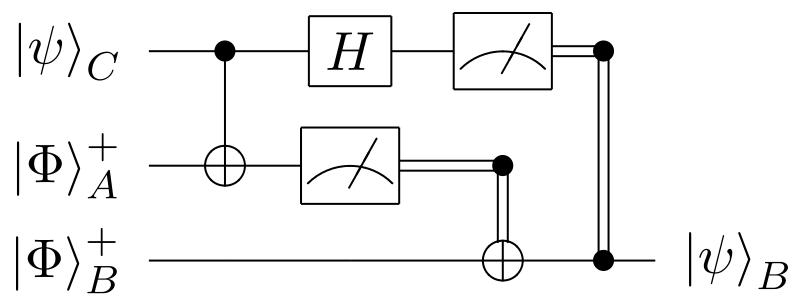

In this circuit, we have a classical logic circuit that conditionally applies a $X$ and/or $Z$ gate.  

The statement that measurement and conditioning commute means with can swap the Measurement followed by Classically-Controllled-X and Classically-Controllled-X by CNOT, and CZ followed by measurements:

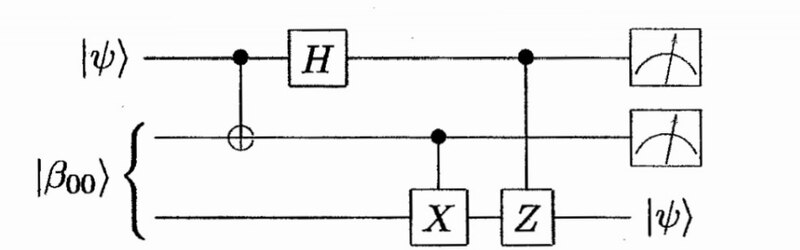

In the next two cells, implement this circuit, make sure to save the statevector of Bob's qubit at the end.

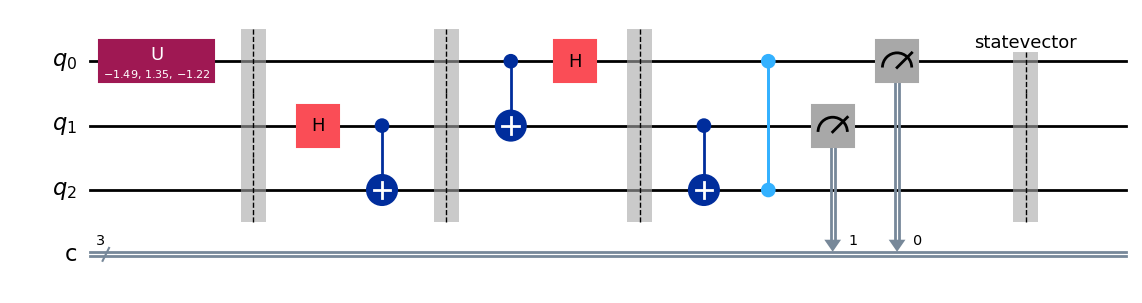

In [16]:
qc = QuantumCircuit(3, 3)

# Prepare a general state
theta, phi, lam = (2*np.random.rand()-1)*np.pi, (2*np.random.rand()-1)*np.pi, (2*np.random.rand()-1)*np.pi
# theta, phi, lam = np.pi / 4, np.pi / 3, 0
qc.u(theta, phi, lam, 0)

#qc.h(0)

qc.barrier()

# Bell pair
qc.h(1)
qc.cx(1, 2)

qc.barrier()

# Bell measurement
qc.cx(0, 1)
qc.h(0)

qc.barrier()

# Use controlled gates to perform part of the teleportation
qc.cx(1, 2)
qc.cz(0, 2)

# Measure final qubit
qc.measure((0, 1), (0, 1))
qc.save_statevector()
qc.draw('mpl')

In the next cell, run the simulation and compare the state vector you found to this initial state.

Instead of using the process fidelity, try computing the exact initial state from the definition of the `[circuit].u(theta,phi,lambda,qubit)` gate from https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.UGate as a numpy array applied to a numpy array [1,0].

In [17]:
#Define a numpy array with your initial state
initial_state = np.array([[np.cos(theta/2),-np.exp(1j*lam)*np.sin(theta/2)],[np.exp(1j*phi)*np.sin(theta/2),np.exp(1j*(phi+lam))*np.cos(theta/2)]]) @ np.array([1,0])

# Simulate final statevector
result = backend.run(qc).result()
state = result.get_statevector()

# Plot Bloch sphere for all qubits (Bob's is qubit 2)
display(array_to_latex(initial_state, prefix="\\text{Initial Statevector} = "),array_to_latex(state, prefix="\\text{Final Statevector} = "))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Exercise 4: Turn It into a Subroutine and generalize for n-qubits

Clearly, having to write this circuit over and over again would be tedious, especially if we need to do it many times in a computation.  Thus, let's now turn the quantum teleportation protocol with deferred measurement (for reasons related to Qiskit's implementation, it requires some annoying hacks to get measurements in subroutines in the preferred way) into a reusable subroutine for a single qubit, and then generalize it to teleport any n-qubit. Then we will test your function using a 3-qubit input state.

***Step 1: Create a single-qubit teleportation subroutine***

Write a function which:
* takes in no inputs

* creates a circuit with 3 qubits

* implement the entire deferred-measurement teleportation protocol except for the measurments

* now, convert your circuit to a gate, using `[gate]=[circuit].to_gate()`

* Give your new gate a name that entertains you, via `[gate].name="[name]"`

* `return` your gate


In [18]:
def teleport_single_qubit():

    """Teleport a single qubit using classical conditionals and return the teleported state."""

    # Circuit with 3 qubits (0: psi, 1: Alice, 2: Bob) and 2 classical bits
    qc = QuantumCircuit(3)

    # Step 1: Create Bell pair between qubit 1 and 2 (Alice and Bob)
    qc.h(1)
    qc.cx(1, 2)
    # qc.barrier()

    # Step 2: Bell-state measurement
    qc.cx(0, 1)
    qc.h(0)
    # qc.barrier()
    qc.cx(1, 2)
    qc.cz(0, 2)

    #Turn the circuit into a gate, name it, and return
    teleport_gate = qc.to_gate()
    teleport_gate.name = "U$_{GT}$"
    return teleport_gate

***Step 2: Generalize to n-qubit teleportation***

* Define a new function that takes as input the number of qubits to teleport
* Create a new circuit with 3 times the number of qubits
* Using a `for loop`, implement the single qubit teleportation gate for your n qubits.  To do this, you invoke `[circuit].append([function_that_creates_gate],[array_of_qubits_to_apply_to]`
  * Note: you will need to decide how to encode your 3n qubits, do you want to put all the $\varphi\rangle$ first? or interleave them with Alice and Bobs qubits?
*Convert your circuit to a gate, give it a name, and return it

In [19]:
def teleport_n_qubits(n):
    total_qubits = 3 * n
    qc = QuantumCircuit(total_qubits)

    # Apply teleportation subroutine
    for i in range(n):
        psi = i
        alice = n + i
        bob = 2 * n + i
        cbit_offset = 2 * i
        qc.append(teleport_single_qubit(), [i, n + i, 2 * n + i])

    #Turn the circuit into a gate, name it, and return

    teleport_n_gate=qc.to_gate()
    teleport_n_gate.name="U$_{nGT}$"
    return teleport_n_gate

***Step 3: Put it all together***

Now, lets prepare a circuit to teleport 3 qubits.
* Create a new circuit with the appropriate number of qubits
* Initialize your 3 $|\varphi\rangle$ qubit to the GHZ-state $\frac{1}{2}(|000\rangle+|111\rangle)$
  * See https://en.wikipedia.org/wiki/Greenberger%E2%80%93Horne%E2%80%93Zeilinger_state
* Put in a barrier
* Append the n-qubit teleportation gate you created
* Measure all the qubits required for the deferred measurment part of the teleportation protocol.
* Save the state vector
* At this point, you should probably draw your circuit, and see if it looks ok.  To do this, you may need to use the function `[circuit].decompose()` in order to get the circuit in terms of basic gates

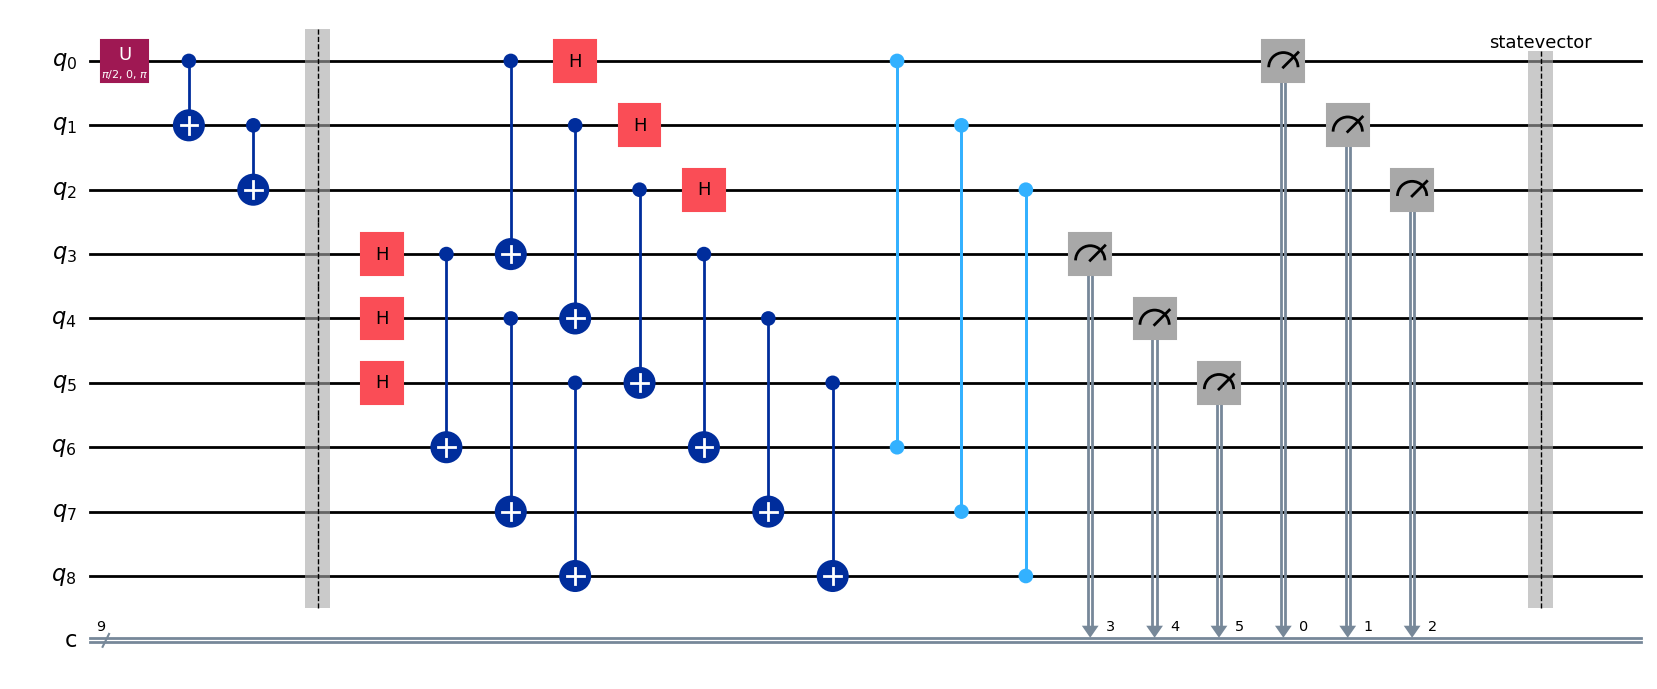

In [20]:
#Create a sufficiently big circuit
ghz = QuantumCircuit(3*3,3*3)

# Prepare the GHZ state
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(1, 2)

ghz.barrier()

# Build teleportation circuit
ghz.append(teleport_n_qubits(3), range(9))
ghz.measure(range(6),range(6))

#Save the state and check your circuit
ghz.save_statevector()
ghz.decompose().decompose().draw('mpl')

Once you are convinced your circuit is correct, set up a `backend.run`.

*Note:* You may need to decompose your circuit to get the simulator to run correctly.

Then check that after running the circuit that your Bob qubits are in the state you expect.

In [21]:
# Simulate
backend = AerSimulator()
result = backend.run(ghz.decompose().decompose()).result()
final_state = result.get_statevector()

# Extract Bob's qubits (qubits 6, 7, 8)
bob_indices = [6, 7, 8]
non_bob_indices = [i for i in range(9) if i not in bob_indices]

# Partial trace to get reduced state of Bob's qubits
bob_state = partial_trace(final_state, non_bob_indices)
sv = bob_state.to_statevector()
# Visualize
display(array_to_latex(sv, prefix="\\text{Final Statevector} = "))

<IPython.core.display.Latex object>

Exercise 5: **Conceptual Questions:**

Discuss the following questions with another team or the Lab instructors.

- Why does teleportation not violate the **no-cloning theorem**?
- What happens to Alice's original qubit state after measurement?
- Why is classical communication necessary for teleportation?
- What would happen if Alice’s measurement results were not sent to Bob?
- How does this enforce causality in quantum communication?
- Discuss the implications for quantum information security.
- Discuss more applications in current relevant fields in both industry and academia

Additional (Optional) Exercise:

One of the bigger uses of teleportation is in "gate teleportation" or "gate injection" as it related to fault-tolerant computation. Explore how to implement this for the CNOT using https://arxiv.org/pdf/quant-ph/9908010.  

**Hint: Look at Fig. 2**